In [165]:
!py --version

Python 3.13.8


In [ ]:
import pandas as pd
import sklearn as skl
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print(f"pandas=={pd.__version__}")
print(f"sklearn=={skl.__version__}")
print(f"matplotlib Learn: {mpl.__version__}")
print(f"seaborn: {sns.__version__}")

pandas: 2.3.3
sklearn: 1.7.2
matplotlib Learn: 3.10.7
seaborn: 0.13.2


In [167]:
RANDOM_STATE = 42

## Описание задачи и признаков

**Цель** - предсказание показателя "Гармония Бессмертия".

Судя по тому, что целевой признак - числовой коэффициент, не сложно предположить, что поставленная задача сводится к решению задачи **регрессии**.

**Признаки:**
| Название | Тип | Мера |
|--------|-------|---------|
| Вектор мощи | числовой | ? |
| Скорость перехода через портал | числовой | ? |
| Приток Силы Потока | числовой | ? |
| Ритм магичекого ядра | числовой | RPM |
| Поток Энергий | числовой | RPM |
| Сила Левого Потока | числовой | ? |
| Сила Правого Потока | числовой | ? |
| Пламя Стихий | числовой | °С |
| Температура вдоха Истока | числовой | °С |
| Температура выдоха Истока | числовой | °С |
| Приток давления Выдоха Истока | числовой | ? |
| Давление вдоха Истока | числовой | ? |
| Давление выдоха Истока | числовой | ? |
| Древний Ветер | числовой | ? |
| Печать Чародея | числовой | % |
| Эмульсия Истока | числовой | ? |
| Дыхание Истока | числовой | ? |
| Тип Вектора Мощи | категориальный | метки |
| Номер пометки | числовой | уникальный номер |
| *Гармония Бессмертия (целевой)* | числовой | ? |

**Особые признаки (формулы):**
| Название | Формула |
|--------|-------|
| Сумма потоков | Сила Левого Потока + Сила Правого Потока
| Общая сила потоков | Сумма потоков + Приток Силы Потока
| Общая сила ядра | Ритм магичекого ядра * Приток Силы Потока
| Общее давление | Приток давления Выдоха Истока + Давление выдоха Истока
| Магическая производительность | Скорость перехода через портал / Эмульсия Истока
| Эффективность ядра | Общая сила ядра / Эмульсия Истока
| Магическая мощность | Эмульсия Истока * Общее давление * (Пламя Стихий - Температура вдоха Истока)

Все формулы, используюцие целевой признак отбрасываются, при их использовании будет явная утечка данных.


## Обработка данных

In [168]:
df = pd.read_csv('portal_data.csv', sep='|', encoding='cp1251', na_values=['-', 'Не определено']).drop('Номер пометки', axis=1)
df

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Температура вдоха Истока,Температура выдоха Истока,Приток давления Выдоха Истока,Давление вдоха Истока,Давление выдоха Истока,Древний Ветер,Печать Чародея,Эмульсия Истока,Дыхание Истока,Гармония Бессмертия,Тип Вектора Мощи
0,1.138,1.54332,289.964,141.318158,6677.380,7.584,7.584,464.006,736,NaN,1.096,NaN,5.947,NaN,7.137,0.082,0.95,0.975,Слабый
1,2.088,NaN,6960.180,144.111767,6828.469,28.204,28.204,635.401,736,581.658,1.331,1.394603,7.282,1.019,10.655,0.287,0.95,0.975,Слабый
2,3.144,4.62996,8379.229,145.220853,7111.811,60.358,60.358,606.002,736,NaN,1.389,NaN,7.574,NaN,13.086,0.259,0.95,0.975,Ниже среднего
3,4.161,6.17328,14724.395,162.050156,7792.630,113.774,113.774,661.471,736,NaN,1.658,NaN,9.007,NaN,18.109,0.358,0.95,0.975,Ниже среднего
4,5.140,7.71660,21636.432,201.513586,8494.777,175.306,175.306,731.494,736,645.642,2.078,NaN,11.197,1.026,26.373,0.522,0.95,0.975,Выше среднего
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11929,5.140,7.71660,21624.934,201.516623,8470.013,175.239,175.239,681.658,736,628.950,2.087,NaN,10.990,1.027,23.803,0.471,1.00,1.000,Выше среднего
11930,6.175,9.25992,29763.213,241.561772,8800.352,245.954,245.954,747.405,736,NaN,2.512,NaN,13.109,NaN,32.671,0.647,1.00,1.000,Выше среднего
11931,7.148,10.80324,39003.867,280.444950,9120.889,332.389,332.389,796.457,736,680.393,2.982,NaN,15.420,1.036,42.104,0.834,1.00,1.000,Сильный
11932,8.206,12.34656,50992.579,323.315332,9300.274,438.024,438.024,892.945,736,NaN,3.594,NaN,18.293,NaN,58.064,1.149,1.00,1.000,Сильный


In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11934 entries, 0 to 11933
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Вектор Мощи                     11934 non-null  float64
 1   Скорость перехода через портал  10731 non-null  float64
 2   Приток Силы Потока              11934 non-null  float64
 3   Ритм магического ядра           11934 non-null  float64
 4   Поток Энергий                   11934 non-null  float64
 5   Сила Левого Потока              11934 non-null  float64
 6   Сила Правого Потока             11934 non-null  float64
 7   Пламя Стихий                    11934 non-null  float64
 8   Температура вдоха Истока        11934 non-null  int64  
 9   Температура выдоха Истока       2387 non-null   float64
 10  Приток давления Выдоха Истока   11934 non-null  float64
 11  Давление вдоха Истока           2439 non-null   float64
 12  Давление выдоха Истока          

In [170]:
df.nunique()

Вектор Мощи                           9
Скорость перехода через портал        9
Приток Силы Потока                11430
Ритм магического ядра              3888
Поток Энергий                     11834
Сила Левого Потока                 4286
Сила Правого Потока                4286
Пламя Стихий                      11772
Температура вдоха Истока              1
Температура выдоха Истока          2368
Приток давления Выдоха Истока       524
Давление вдоха Истока                 1
Давление выдоха Истока             4209
Древний Ветер                        19
Печать Чародея                     8496
Эмульсия Истока                     696
Дыхание Истока                       51
Гармония Бессмертия                  26
Тип Вектора Мощи                      4
dtype: int64

In [171]:
cols_to_drop = {'Температура вдоха Истока', 'Давление вдоха Истока'}

In [172]:
cols_to_drop = cols_to_drop.union(set([col for col in df.columns if df[col].isna().mean() >= 0.75]))
cols_to_drop

{'Давление вдоха Истока',
 'Древний Ветер',
 'Температура вдоха Истока',
 'Температура выдоха Истока'}

In [173]:
all_rows = df.shape[0]
df = df[df.isna().mean(axis=1) < 0.5]
print(f'Бесполезных строк: {all_rows - df.shape[0]}')

Бесполезных строк: 0


In [174]:
df['Сумма потоков'] = df['Сила Левого Потока'] + df['Сила Правого Потока']
df['Общая сила потоков'] = df['Сумма потоков'] + df['Приток Силы Потока']
df['Общая сила ядра'] = df['Ритм магического ядра'] * df['Приток Силы Потока']
df['Общее давление'] = df['Приток давления Выдоха Истока'] + df['Давление выдоха Истока']
df['Магическая производительность'] = df['Скорость перехода через портал'] / df['Эмульсия Истока']
df['Эффективность ядра'] = df['Общая сила ядра'] / df['Эмульсия Истока']
df['Магическая мощность'] = df['Эмульсия Истока'] * df['Общее давление'] * (df['Пламя Стихий'] - df['Температура вдоха Истока'])

In [175]:
cols_to_drop = cols_to_drop.union(set(['Сила Левого Потока', 'Сила Правого Потока', 'Сумма потоков', 'Приток Силы Потока', 'Приток давления Выдоха Истока', 'Давление выдоха Истока', 'Вектор Мощи', 'Скорость перехода через портал']))
df.drop(cols_to_drop, axis=1, inplace=True)

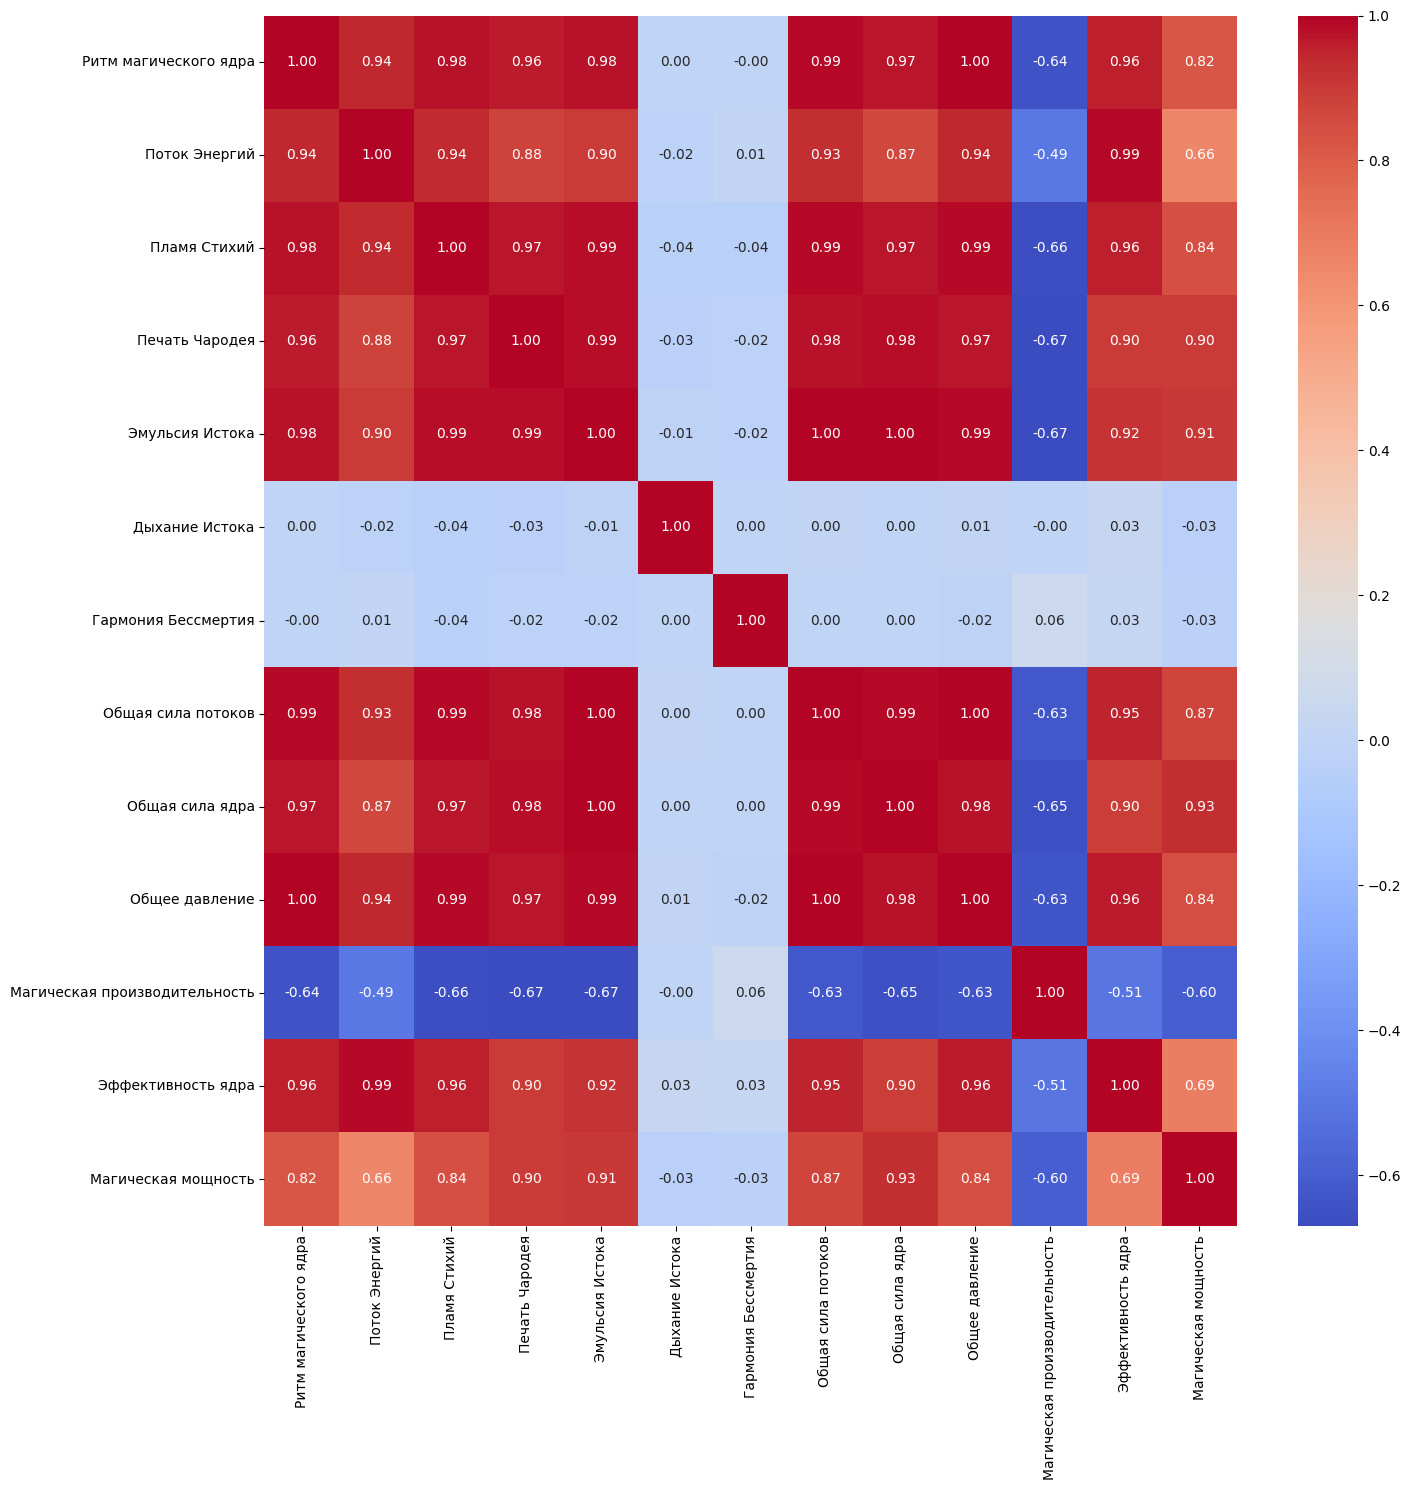

In [176]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.drop('Тип Вектора Мощи', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

In [ ]:
y = df['Гармония Бессмертия']
X = df.drop('Гармония Бессмертия', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)